In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
from pathlib import Path
from src.dataset import S2TIFDataSet
from src.misc import select_patches_from_dataset
from torch.utils.data import DataLoader
import tifffile
import torchvision.transforms.functional as TF


## dataset

In [3]:
file_paths = select_patches_from_dataset("./data/cloudsen12_initial_cloudfree_scribble.csv", "./data")
len(file_paths)

1757

In [4]:
USER = "di54xat"
ROOT_HPC = Path("/dss/dsstbyfs02/pn49ci/pn49ci-dss-0026")
USER_PATH = ROOT_HPC / f"{USER}"
DATA_PATH_HPC = ROOT_HPC / "cloudsen12" / "data"

ROOT_LOCAL = Path("$HOME/cloudsen12")
DATA_PATH_LOCAL = ROOT_LOCAL / "data"

USE_HPC = False

if USE_HPC:
    ROOT = ROOT_HPC
    DATA_PATH = DATA_PATH_HPC
else:
    ROOT = ROOT_LOCAL
    DATA_PATH = DATA_PATH_LOCAL

DATA_ROOT = DATA_PATH

In [5]:
DATA_PATH

PosixPath('$HOME/cloudsen12/data')

### load data into dataloader

In [6]:

# Train/val split (80/20)
split_idx = int(0.8 * len(file_paths))
train_names = file_paths[:split_idx]
val_names = file_paths[split_idx:]


# Create datasets and dataloaders
train_dataset = S2TIFDataSet(train_names, DATA_ROOT, omitt_band_idxs=[])
val_dataset = S2TIFDataSet(val_names, DATA_ROOT, omitt_band_idxs=[])

train_loader = DataLoader(
    train_dataset,
    batch_size=12,
    shuffle=True,
    num_workers=10,
    prefetch_factor=8,
    drop_last=True,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=10,
    prefetch_factor=8,
    pin_memory=True,
)

In [7]:
len(train_dataset)

1405

### check img shape

In [8]:
img = tifffile.imread(train_dataset.img_paths[0])

X = TF.to_tensor(img)

X.shape # should be ok

torch.Size([15, 509, 509])

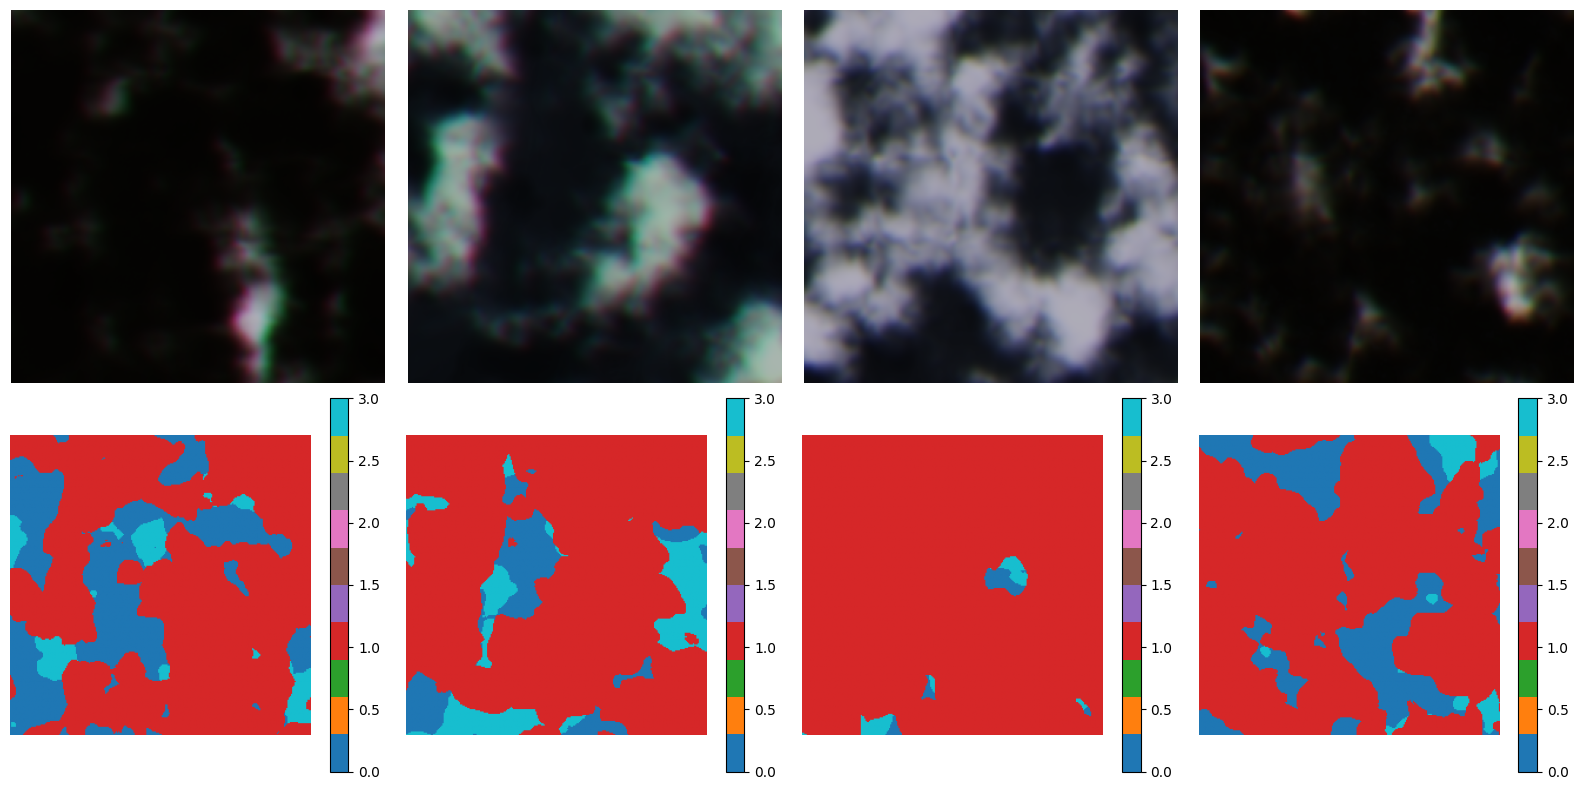

In [12]:
# check what the loader loads
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    rand_id = int(random.random() * len(train_dataset))
    sample_x, sample_y = train_dataset[rand_id]

    # Plot input
    axes[0, i].imshow(sample_x[:3].permute(1,2,0).numpy())
    axes[0, i].axis("off")

    # Plot target
    im = axes[1, i].imshow(sample_y.numpy(), cmap="tab10", vmin=0, vmax=3)
    
    fig.colorbar(im, ax=axes[1, i])

    axes[1, i].axis("off")

#plt.colorbar()
plt.tight_layout()
plt.show()

## model init

In [165]:
import torch.nn as nn
import torch

In [166]:
device = "cpu"

In [ ]:
class DoubleConv(nn.Module):
    """Two consecutive convolution blocks with BatchNorm and ReLU.

    This is the basic building block of U-Net.
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """Basic U-Net for semantic segmentation.

    Args:
        in_channels: Number of input channels (1 for binary/grayscale)
        num_classes: Number of output classes (3 for our problem)
        base_channels: Number of channels in first layer (default: 32)
    """

    def __init__(self, in_channels=1, num_classes=3, base_channels=32):
        super().__init__()

        # ENCODER
        self.enc1 = DoubleConv(in_channels, base_channels)  # 32 channels
        self.enc2 = DoubleConv(base_channels, base_channels * 2)  # 64 channels
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)  # 128 channels
        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8)  # 256 channels

        self.pool = nn.MaxPool2d(2)  # Downsampling by 2

        # BOTTLENECK (Bottom of U)
        self.bottleneck = DoubleConv(
            base_channels * 8, base_channels * 16
        )  # 512 channels

        # DECODER
        self.up4 = nn.ConvTranspose2d(
            base_channels * 16, base_channels * 8, kernel_size=2, stride=2
        )
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(
            base_channels * 8, base_channels * 4, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4, base_channels * 2, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2, base_channels, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        # FINAL LAYER: 1×1 convolution to get class scores
        self.out = nn.Conv2d(base_channels, num_classes, kernel_size=1)

    def forward(self, x):
        # Encoder path (save features for skip connections)
        enc1 = self.enc1(x)  # 1024×1024×32
        enc2 = self.enc2(self.pool(enc1))  # 512×512×64
        enc3 = self.enc3(self.pool(enc2))  # 256×256×128
        enc4 = self.enc4(self.pool(enc3))  # 128×128×256

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(enc4))  # 64×64×512

        # Decoder path (with skip connections)
        dec4 = self.up4(bottleneck)  # 128×128×256
        dec4 = torch.cat([dec4, enc4], dim=1)  # Concatenate skip connection
        dec4 = self.dec4(dec4)  # 128×128×256

        dec3 = self.up3(dec4)  # 256×256×128
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)  # 256×256×128

        dec2 = self.up2(dec3)  # 512×512×64
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)  # 512×512×64

        dec1 = self.up1(dec2)  # 1024×1024×32
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)  # 1024×1024×32

        # Final output
        out = self.out(dec1)  # 1024×1024×3
        return out


# Create model and inspect
model = UNet(in_channels=12, num_classes=4validationva



validation, base_channels=32).to(device)
print(f"\nModel Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test with
#24×1024 input
dummy_input = torch.randn(1, 12, 256, 256).to(device)
dummy_output = model(dummy_input)


Model Parameters: 7,765,699


In [168]:
from torchinfo import summary

# Create detailed model summary
summary(
    model,
    input_size=(1, 12, 256, 256),  # (batch_size, channels, height, width)
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"],
    verbose=1,
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
UNet (UNet)                              [1, 12, 256, 256]    [1, 3, 256, 256]     --                   True
├─DoubleConv (enc1)                      [1, 12, 256, 256]    [1, 32, 256, 256]    --                   True
│    └─Sequential (block)                [1, 12, 256, 256]    [1, 32, 256, 256]    --                   True
│    │    └─Conv2d (0)                   [1, 12, 256, 256]    [1, 32, 256, 256]    3,456                True
│    │    └─BatchNorm2d (1)              [1, 32, 256, 256]    [1, 32, 256, 256]    64                   True
│    │    └─ReLU (2)                     [1, 32, 256, 256]    [1, 32, 256, 256]    --                   --
│    │    └─Conv2d (3)                   [1, 32, 256, 256]    [1, 32, 256, 256]    9,216                True
│    │    └─BatchNorm2d (4)              [1, 32, 256, 256]    [1, 32, 256, 256]    64                   True
│    │    └─ReLU

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
UNet (UNet)                              [1, 12, 256, 256]    [1, 3, 256, 256]     --                   True
├─DoubleConv (enc1)                      [1, 12, 256, 256]    [1, 32, 256, 256]    --                   True
│    └─Sequential (block)                [1, 12, 256, 256]    [1, 32, 256, 256]    --                   True
│    │    └─Conv2d (0)                   [1, 12, 256, 256]    [1, 32, 256, 256]    3,456                True
│    │    └─BatchNorm2d (1)              [1, 32, 256, 256]    [1, 32, 256, 256]    64                   True
│    │    └─ReLU (2)                     [1, 32, 256, 256]    [1, 32, 256, 256]    --                   --
│    │    └─Conv2d (3)                   [1, 32, 256, 256]    [1, 32, 256, 256]    9,216                True
│    │    └─BatchNorm2d (4)              [1, 32, 256, 256]    [1, 32, 256, 256]    64                   True
│    │    └─ReLU

In [169]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=2, eta_min=0.0)

In [170]:
USE_HPC

False

In [171]:
from torch.utils.tensorboard import SummaryWriter


In [18]:
EXPERIMENT_GROUP = "LWF-DLR"
EXPERIMENT_ID = "cloud_baseline_unet_001"

if USE_HPC:
    EXPERIMENT_DIR = USER_PATH / f"experiments/{EXPERIMENT_GROUP}"
else:
    EXPERIMENT_DIR = ROOT / "experiments" / EXPERIMENT_GROUP

EXPERIMENT_DIR = EXPERIMENT_DIR / EXPERIMENT_ID
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

writer = SummaryWriter(log_dir=str(EXPERIMENT_DIR))

checkpoint_dir = EXPERIMENT_DIR / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)


In [172]:
def validate_model(model, dataloader, criterion, device):
    """Run validation and return loss."""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Validation", leave=False):
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    return {"loss": avg_loss}


def save_checkpoint(
    model,
    optimizer,
    epoch,
    global_step,
    val_loss,
    checkpoint_dir,
    is_best=False,
    prefix="checkpoint",
):
    """Save model checkpoint."""
    checkpoint_path = checkpoint_dir / f"{prefix}_step_{global_step}.pth"

    torch.save(
        {
            "epoch": epoch,
            "global_step": global_step,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
        },
        checkpoint_path,
    )

    if is_best:
        best_path = checkpoint_dir / "best_model.pth"
        torch.save(
            {
                "epoch": epoch,
                "global_step": global_step,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
            },
            best_path,
        )
        print(f"  → Best model saved! (Val Loss: {val_loss:.4f})")

    return checkpoint_path


In [173]:
from tqdm.auto import tqdm


/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [174]:

num_epochs = 5
num_classes = 3
class_names = ["clear", "shadow", "cloud"]

# Step-based validation settings
val_every_n_steps = 250  # Validate every 250 steps
val_every_n_steps_warmup = 50  # Validate every 50 steps during warmup
warmup_steps = 100  # First 100 steps use warmup frequency
save_every_n_steps = 20  # Save checkpoint every 20 steps

# Global tracking
global_step = 0
validation_cycle = 0
best_val_loss = float("inf")

# Training metrics accumulator (since last validation)
train_running_loss_since_val = 0.0
train_samples_since_val = 0

print(f"{'=' * 80}")
print(f"TRAINING CONFIGURATION")
print(f"{'=' * 80}")
print(f"Epochs: {num_epochs}")
print(f"Step-based validation:")
print(
    f"  - Warmup: every {val_every_n_steps_warmup} steps for first {warmup_steps} steps"
)
print(f"  - Normal: every {val_every_n_steps} steps")
print(f"Checkpoint saving: every {save_every_n_steps} steps + best model")
print(f"{'=' * 80}\n")

for epoch in range(num_epochs):
    print(f"\n{'=' * 60}")
    print(f"Epoch {epoch + 1}/{num_epochs}")
    print(f"{'=' * 60}")

    model.train()

    for batch_idx, (inputs, targets) in enumerate(
        tqdm(train_loader, desc=f"Training Epoch {epoch + 1}")
    ):
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        # Accumulate training metrics
        batch_size = inputs.size(0)
        train_running_loss_since_val += loss.item() * batch_size
        train_samples_since_val += batch_size

        # Log learning rate every step
        writer.add_scalar(
            "Train/learning_rate", optimizer.param_groups[0]["lr"], global_step
        )

        global_step += 1

        # ======================
        # STEP-BASED VALIDATION
        # ======================

        # Determine validation frequency (warmup vs normal)
        if global_step <= warmup_steps:
            current_val_freq = val_every_n_steps_warmup
        else:
            current_val_freq = val_every_n_steps

        # Check if it's time to validate
        if global_step % current_val_freq == 0:
            validation_cycle += 1

            # Log averaged training loss since last validation
            if train_samples_since_val > 0:
                train_loss_avg = train_running_loss_since_val / train_samples_since_val
                writer.add_scalar(
                    "Train/total_loss_interval", train_loss_avg, global_step
                )

            # Reset training accumulators
            train_running_loss_since_val = 0.0
            train_samples_since_val = 0

            # Run validation
            val_metrics = validate_model(model, val_loader, criterion, device)

            # ===========================
            # TensorBoard Logging
            # ===========================

            # Loss
            writer.add_scalar("Val/total_loss", val_metrics["loss"], global_step)

            # Console output
            print(
                f"\n[Step {global_step} | Cycle {validation_cycle} | Epoch {epoch + 1}]"
            )
            print(f"  Val Loss: {val_metrics['loss']:.4f}")

            # ===========================
            # Checkpoint Saving
            # ===========================

            # Check if this is the best model (lower loss is better)
            is_best = val_metrics["loss"] < best_val_loss
            if is_best:
                best_val_loss = val_metrics["loss"]

            # Save checkpoint every N steps or if best
            if global_step % save_every_n_steps == 0 or is_best:
                save_checkpoint(
                    model,
                    optimizer,
                    epoch,
                    global_step,
                    val_metrics["loss"],
                    checkpoint_dir,
                    is_best=is_best,
                )
                if global_step % save_every_n_steps == 0:
                    print(f"  → Checkpoint saved at step {global_step}")

            # Return to training mode
            model.train()

    # Update learning rate at end of epoch
    scheduler.step()
    print(f"\nEpoch {epoch + 1} complete. LR: {optimizer.param_groups[0]['lr']:.6f}")

# ===========================
# Final Save
# ===========================
print(f"\n{'=' * 60}")
print(f"TRAINING COMPLETE")
print(f"{'=' * 60}")
print(f"Total steps: {global_step}")
print(f"Validation cycles: {validation_cycle}")
print(f"Best Val Loss: {best_val_loss:.4f}")

# Save final model
final_path = checkpoint_dir / "final_model.pth"
torch.save(
    {
        "epoch": num_epochs,
        "global_step": global_step,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_loss": best_val_loss,
    },
    final_path,
)
print(f"\nFinal model saved to: {final_path}")
print(f"Best model saved to: {checkpoint_dir / 'best_model.pth'}")
print(f"TensorBoard logs: {EXPERIMENT_DIR}")
print(f"\nTo view logs, run: tensorboard --logdir={EXPERIMENT_DIR}")
print(f"{'=' * 60}")

# Close TensorBoard writer
writer.close()


TRAINING CONFIGURATION
Epochs: 5
Step-based validation:
  - Warmup: every 50 steps for first 100 steps
  - Normal: every 250 steps
Checkpoint saving: every 20 steps + best model


Epoch 1/5


Training Epoch 1:   0%|          | 0/117 [00:00<?, ?it/s]/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 8, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/dss/dsshome1/00/di54xat/cloudsen12/.venv/lib64/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Epoch 1:   0%|          | 0/117 [00:48<?, ?it/s]


KeyboardInterrupt: 

## test on other files